
# Custom Random Forest From Scratch — Customer Churn Prediction

Notebook này tự xây dựng:
- Decision Tree
- Random Forest

KHÔNG dùng:
```python
RandomForestClassifier()
DecisionTreeClassifier()
```

Chỉ dùng:
- numpy
- pandas

để tự xây dựng thuật toán.


## Cell 1 — Import thư viện

In [1]:

import numpy as np
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)


## Cell 2 — Load dữ liệu

In [2]:

processed_dir = Path("processed_data")

X_train = pd.read_csv(processed_dir / "X_train_resampled.csv")
X_test = pd.read_csv(processed_dir / "X_test_scaled.csv")

y_train = pd.read_csv(
    processed_dir / "y_train_resampled.csv",
    header=None
).values.ravel()

y_test = pd.read_csv(
    processed_dir / "y_test.csv",
    header=None
).values.ravel()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (12282, 11)
X_test : (1926, 11)
y_train: (12282,)
y_test : (1926,)



## Cell 3 — Hàm Gini Impurity

Gini dùng để đo độ hỗn loạn của dữ liệu trong node.


In [3]:

def gini(y):
    classes = np.unique(y)

    impurity = 1

    for c in classes:
        p = np.sum(y == c) / len(y)
        impurity -= p ** 2

    return impurity



## Cell 4 — Hàm chia dữ liệu


In [4]:

def split_dataset(X, y, feature_index, threshold):

    left_mask = X[:, feature_index] <= threshold
    right_mask = X[:, feature_index] > threshold

    X_left = X[left_mask]
    y_left = y[left_mask]

    X_right = X[right_mask]
    y_right = y[right_mask]

    return X_left, y_left, X_right, y_right



## Cell 5 — Tìm split tốt nhất


In [5]:

def best_split(X, y, max_features):

    n_samples, n_features = X.shape

    feature_indices = np.random.choice(
        n_features,
        max_features,
        replace=False
    )

    best_gini = 999
    best_feature = None
    best_threshold = None

    for feature in feature_indices:

        thresholds = np.unique(X[:, feature])

        for threshold in thresholds:

            X_left, y_left, X_right, y_right = split_dataset(
                X,
                y,
                feature,
                threshold
            )

            if len(y_left) == 0 or len(y_right) == 0:
                continue

            gini_left = gini(y_left)
            gini_right = gini(y_right)

            weighted_gini = (
                len(y_left) / len(y) * gini_left
                + len(y_right) / len(y) * gini_right
            )

            if weighted_gini < best_gini:
                best_gini = weighted_gini
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold



## Cell 6 — Node Decision Tree


In [6]:

class Node:

    def __init__(
        self,
        feature=None,
        threshold=None,
        left=None,
        right=None,
        value=None
    ):

        self.feature = feature
        self.threshold = threshold

        self.left = left
        self.right = right

        self.value = value



## Cell 7 — Custom Decision Tree


In [7]:

class CustomDecisionTree:

    def __init__(
        self,
        max_depth=10,
        min_samples_split=2,
        max_features=None
    ):

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features

        self.root = None

    def fit(self, X, y):

        X = np.array(X)
        y = np.array(y)

        if self.max_features is None:
            self.max_features = int(np.sqrt(X.shape[1]))

        self.root = self.build_tree(X, y, depth=0)

    def build_tree(self, X, y, depth):

        n_samples = X.shape[0]
        n_classes = len(np.unique(y))

        if (
            depth >= self.max_depth
            or n_classes == 1
            or n_samples < self.min_samples_split
        ):

            leaf_value = self.most_common_label(y)
            return Node(value=leaf_value)

        feature, threshold = best_split(
            X,
            y,
            self.max_features
        )

        if feature is None:
            leaf_value = self.most_common_label(y)
            return Node(value=leaf_value)

        X_left, y_left, X_right, y_right = split_dataset(
            X,
            y,
            feature,
            threshold
        )

        left_child = self.build_tree(
            X_left,
            y_left,
            depth + 1
        )

        right_child = self.build_tree(
            X_right,
            y_right,
            depth + 1
        )

        return Node(
            feature=feature,
            threshold=threshold,
            left=left_child,
            right=right_child
        )

    def most_common_label(self, y):
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]

    def predict_one(self, x, node):

        if node.value is not None:
            return node.value

        if x[node.feature] <= node.threshold:
            return self.predict_one(x, node.left)

        return self.predict_one(x, node.right)

    def predict(self, X):

        X = np.array(X)

        predictions = [
            self.predict_one(x, self.root)
            for x in X
        ]

        return np.array(predictions)



## Cell 8 — Bootstrap Sampling


In [8]:

def bootstrap_sample(X, y):

    n_samples = X.shape[0]

    indices = np.random.choice(
        n_samples,
        n_samples,
        replace=True
    )

    return X[indices], y[indices]



## Cell 9 — Custom Random Forest


In [9]:

class CustomRandomForest:

    def __init__(
        self,
        n_trees=20,
        max_depth=10,
        min_samples_split=2,
        max_features=None
    ):

        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features

        self.trees = []

    def fit(self, X, y):

        X = np.array(X)
        y = np.array(y)

        self.trees = []

        for i in range(self.n_trees):

            X_sample, y_sample = bootstrap_sample(X, y)

            tree = CustomDecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features
            )

            tree.fit(X_sample, y_sample)

            self.trees.append(tree)

            print(f"Đã train cây thứ {i+1}")

    def predict(self, X):

        tree_predictions = np.array([
            tree.predict(X)
            for tree in self.trees
        ])

        tree_predictions = np.swapaxes(tree_predictions, 0, 1)

        predictions = []

        for preds in tree_predictions:

            values, counts = np.unique(
                preds,
                return_counts=True
            )

            predictions.append(values[np.argmax(counts)])

        return np.array(predictions)

    def predict_proba(self, X):

        tree_predictions = np.array([
            tree.predict(X)
            for tree in self.trees
        ])

        tree_predictions = np.swapaxes(tree_predictions, 0, 1)

        probabilities = []

        for preds in tree_predictions:

            prob_class_1 = np.mean(preds == 1)

            probabilities.append([
                1 - prob_class_1,
                prob_class_1
            ])

        return np.array(probabilities)



## Cell 10 — Train Custom Random Forest


In [10]:

rf_model = CustomRandomForest(
    n_trees=30,
    max_depth=10,
    min_samples_split=10,
    max_features=5
)

rf_model.fit(X_train.values, y_train)

print("Train thành công.")


Đã train cây thứ 1
Đã train cây thứ 2
Đã train cây thứ 3
Đã train cây thứ 4
Đã train cây thứ 5
Đã train cây thứ 6
Đã train cây thứ 7
Đã train cây thứ 8
Đã train cây thứ 9
Đã train cây thứ 10
Đã train cây thứ 11
Đã train cây thứ 12
Đã train cây thứ 13
Đã train cây thứ 14
Đã train cây thứ 15
Đã train cây thứ 16
Đã train cây thứ 17
Đã train cây thứ 18
Đã train cây thứ 19
Đã train cây thứ 20
Đã train cây thứ 21
Đã train cây thứ 22
Đã train cây thứ 23
Đã train cây thứ 24
Đã train cây thứ 25
Đã train cây thứ 26
Đã train cây thứ 27
Đã train cây thứ 28
Đã train cây thứ 29
Đã train cây thứ 30
Train thành công.



## Cell 11 — Predict


In [11]:

y_pred_rf = rf_model.predict(X_test.values)

y_prob_rf = rf_model.predict_proba(X_test.values)[:, 1]

prediction_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf,
    "Probability": y_prob_rf
})

prediction_df.head()


,Actual,Predicted,Probability
0,0,1,0.766667
1,0,0,0.000000
2,1,0,0.266667
3,0,0,0.033333
4,1,1,0.900000



## Cell 12 — Evaluate model


In [12]:

accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
auc = roc_auc_score(y_test, y_prob_rf)

print("=" * 50)
print("KẾT QUẢ CUSTOM RANDOM FOREST")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

print("=" * 50)


KẾT QUẢ CUSTOM RANDOM FOREST
Accuracy : 0.8370
Precision: 0.5826
Recall   : 0.6872
F1-score : 0.6306
AUC      : 0.8497



## Cell 13 — Classification Report


In [13]:

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Không churn (0)",
            "Churn (1)"
        ]
    )
)


                 precision    recall  f1-score   support

Không churn (0)       0.92      0.88      0.90      1536
      Churn (1)       0.58      0.69      0.63       390

       accuracy                           0.84      1926
      macro avg       0.75      0.78      0.76      1926
   weighted avg       0.85      0.84      0.84      1926




## Cell 14 — Confusion Matrix


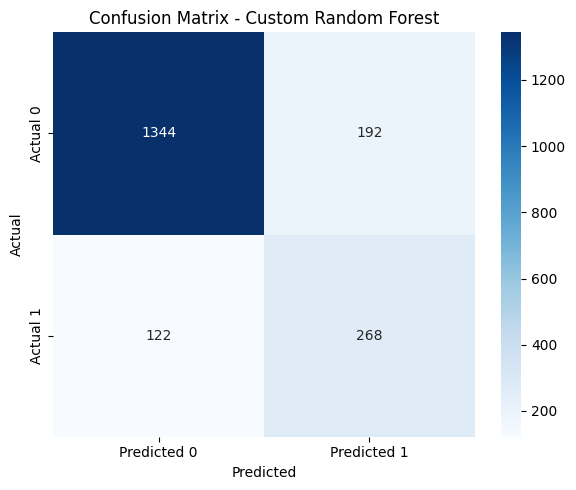

In [14]:

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.title("Confusion Matrix - Custom Random Forest")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()



## Cell 15 — ROC Curve


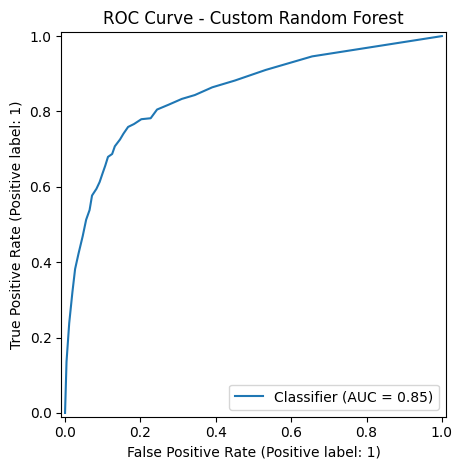

In [15]:

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title("ROC Curve - Custom Random Forest")

plt.tight_layout()
plt.show()



## Cell 16 — Save results


In [16]:

results = pd.DataFrame({
    "Model": ["Custom Random Forest"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1],
    "AUC": [auc]
})

results.to_csv(
    processed_dir / "custom_random_forest_results.csv",
    index=False
)

prediction_df.to_csv(
    processed_dir / "custom_random_forest_predictions.csv",
    index=False
)

print("Đã lưu kết quả.")

display(results)


Đã lưu kết quả.


,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Custom Random Forest,0.836968,0.582609,0.687179,0.630588,0.849747
